# A Neural Probabilistic Language Model
**Authors:** Yoshua Bengio, Réjean Ducharme, Pascal Vincent, Christian Jauvin (Journal of Machine Learning Research 3, 2003)

# https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

## Abstract
This paper proposes a neural network approach to statistical language modeling that jointly learns a distributed representation for each word and a probability function for word sequences expressed in terms of these representations. By representing words as points in a continuous vector space rather than as discrete symbols, the model can generalize to word sequences unseen during training whenever they are composed of words semantically or syntactically similar to those in previously observed sequences. Experiments on the Brown corpus and the much larger Associated Press (AP) News corpus show that this approach significantly reduces test-set perplexity relative to state-of-the-art n-gram models, while also making effective use of longer contexts.

## Problems
- **Curse of dimensionality in discrete sequence modeling:** Modeling the joint distribution of $n$ discrete variables (e.g., words from a vocabulary $V$) requires up to $|V|^n - 1$ free parameters, making direct estimation intractable for natural language.
- **Limited context in n-gram models:** Traditional back-off/interpolated n-gram models (e.g., trigrams) only condition on the previous $n-1$ words (typically $n=3$), ignoring longer-range dependencies due to data sparsity.
- **No notion of word similarity:** N-gram models treat all discrete word combinations independently; encountering an unseen sequence such as "A dog was running in a room" does not benefit from having seen a semantically similar sequence like "The cat is walking in the bedroom," since "dog"/"cat," "a"/"the," and "room"/"bedroom" are treated as unrelated symbols.
- **Scalability of neural approaches:** Prior neural methods for high-dimensional discrete distributions had not been demonstrated at the scale of large vocabularies (tens of thousands of words) and large corpora (millions to tens of millions of examples) required for practical language modeling.

## Proposed Solutions
The core idea combines three steps:
1. Associate each vocabulary word $i$ with a real-valued distributed **feature vector** $C(i) \in \mathbb{R}^m$ (with $m \ll |V|$), stored as rows of a $|V| \times m$ matrix $C$.
2. Express the joint probability of a word sequence as a product of conditional probabilities:
$$\hat{P}(w_1^T) = \prod_{t=1}^{T} \hat{P}(w_t \mid w_1^{t-1})$$
approximated using a fixed context window of the previous $n-1$ words, via a function $g$ (a feed-forward neural network) mapping feature vectors of context words to a probability distribution over the next word:
$$f(i, w_{t-1}, \ldots, w_{t-n+1}) = g(i, C(w_{t-1}), \ldots, C(w_{t-n+1}))$$
3. Learn the feature vectors $C$ and the parameters $\omega$ of $g$ **simultaneously** by maximizing penalized log-likelihood, so that similar words obtain nearby feature vectors and the smooth probability function transfers probability mass across combinatorially many "neighboring" sequences.

A parallel implementation strategy (data-parallel and parameter-parallel across output units) is proposed to make training feasible for large vocabularies and corpora.

## Purpose
The central motivation is to fight the curse of dimensionality "with its own weapons": rather than restricting or discretizing the conditioning context (as n-gram back-off/smoothing does), the model learns a compact, smooth, distributed representation that allows a single training sentence to inform the model about an exponential number of semantically related sentences, thereby improving generalization, especially for contexts not observed verbatim in training, and enabling effective use of longer contextual windows.

## Methodology

### Model Architecture
The neural network computes unnormalized log-probabilities (scores) $y$ for every vocabulary word, followed by a softmax:
$$y = b + Wx + U\tanh(d + Hx) \quad (1)$$
$$\hat{P}(w_t \mid w_{t-1}, \ldots, w_{t-n+1}) = \frac{e^{y_{w_t}}}{\sum_i e^{y_i}}$$
where:
- $x = (C(w_{t-1}), \ldots, C(w_{t-n+1}))$ is the concatenation of context word feature vectors,
- $h$ = number of hidden units, $m$ = number of features per word,
- Free parameters $\theta = (b, d, W, U, H, C)$: output biases $b$ ($|V|$), hidden biases $d$ ($h$), hidden-to-output weights $U$ ($|V| \times h$), optional direct word-features-to-output weights $W$ ($|V| \times (n-1)m$, settable to 0), hidden layer weights $H$ ($h \times (n-1)m$), and word features $C$ ($|V| \times m$).
- Total parameter count is $|V|(1 + nm + h) + h(1 + (n-1)m)$, scaling **linearly** with vocabulary size and context order (a major improvement over the exponential scaling of naive discrete joint models).

### Training
Parameters are learned via **stochastic gradient ascent** on penalized log-likelihood:
$$L = \frac{1}{T}\sum_t \log f(w_t, w_{t-1}, \ldots, w_{t-n+1}; \theta) + R(\theta)$$
with update rule $\theta \leftarrow \theta + \epsilon \frac{\partial \log \hat{P}(w_t|w_{t-1},\ldots,w_{t-n+1})}{\partial \theta}$, using a decreasing learning rate schedule $\epsilon_t = \epsilon_0/(1+rt)$, and a weight decay regularization term $R(\theta)$ applied to $W$, $U$, $H$, $C$ (not biases).

### Parallelization
Given the computational bottleneck of computing output-layer activations over the full vocabulary, the authors implement:
- **Data-parallel processing** on shared-memory machines (asynchronous parameter updates).
- **Parameter-parallel processing** on Linux clusters (32×2 CPUs, Myrinet network, MPI), partitioning the output layer across CPUs, since output-unit computation accounts for approximately 99.7% of total computation in their largest configuration ($|V|=17{,}964$, $h=60$, $n=6$, $m=100$).

### Mixture with N-gram Models
Neural network output probabilities are optionally combined (mixed) with an interpolated trigram model's predictions (fixed weight, learned weight, or frequency-conditional weights), motivated by the observation that the two model types make errors in different contexts.

### Datasets and Baselines
- **Brown corpus:** 1,181,041 words (800K train / 200K validation / 181,041 test), vocabulary reduced to $|V|=16{,}383$ after merging rare words.
- **AP News corpus:** ~14M training words, ~1M validation words, ~1M test words, vocabulary reduced to $|V|=17{,}964$.
- **Baselines:** interpolated (deleted interpolation) trigram, modified Kneser-Ney back-off n-grams (orders 3–5), and class-based back-off n-grams (varying number of classes), all implemented via the SRI Language Modeling toolkit.
- **Evaluation metric:** test-set **perplexity**, i.e., the geometric average of $1/\hat{P}(w_t|w_1^{t-1})$, equivalent to the exponential of average negative log-likelihood.

## Results

| Model (Brown corpus) | n | h | m | Test Perplexity |
|---|---|---|---|---|
| Deleted Interpolation trigram | 3 | – | – | 336 |
| Best Kneser-Ney back-off | 3–5 | – | – | 321 |
| Best class-based back-off (500 classes) | 3–5 | – | – | 312 |
| Best MLP (MLP10, mixed with trigram) | 5 | 100 | 30 | **252** |

- On the **Brown corpus**, the best neural network configuration (MLP10, with mixing) achieved a test perplexity approximately **24% lower** than the best n-gram model (class-based, 500 classes) and **33% lower** than the deleted interpolation trigram.
- On the **AP News corpus**, the best neural model (MLP10: $n=6$, $h=60$, $m=100$, with direct connections and trigram mixing) achieved a test perplexity of **109**, versus 117 for the best Kneser-Ney back-off model (order 5) — an approximate **8%** reduction, a smaller gap attributed to only 5 training epochs being feasible (~3 weeks on 40 CPUs).
- **Effect of context length:** Increasing context from $n=3$ to $n=5$ improved neural network perplexity on Brown (e.g., MLP7→MLP1: 293→268 test perplexity) but did not similarly benefit n-gram models, indicating the neural approach better exploits longer contexts.
- **Effect of hidden units:** Models with

# Mathematical and Statistical Content Summary

## 1. Curse of Dimensionality — Parameter Count for Joint Discrete Distributions
$$100000^{10} - 1 = 10^{50} - 1$$

**Explanation:** Illustrates that modeling the joint distribution of 10 consecutive words from a 100,000-word vocabulary naively requires an astronomically large number of free parameters. This motivates the entire paper: discrete joint distributions over long contexts are intractable to estimate directly from any realistic amount of data.

## 2. Chain Rule Decomposition of Sequence Probability
$$\hat{P}(w_1^T) = \prod_{t=1}^{T} \hat{P}(w_t \mid w_1^{t-1})$$

**Explanation:** Any joint probability over a word sequence can be exactly factored into a product of conditional "next-word given history" probabilities. This is the standard mathematical foundation of statistical language modeling — the paper's task reduces to estimating $\hat{P}(w_t | w_1^{t-1})$ well.

## 3. N-gram Approximation
$$\hat{P}(w_t \mid w_1^{t-1}) \approx \hat{P}(w_t \mid w_{t-n+1}^{t-1})$$

**Explanation:** Since conditioning on the entire history is infeasible, n-gram models truncate the context to only the last $n-1$ words. This approximation trades statistical tractability for loss of long-range context — a limitation the paper's neural approach aims to overcome.

## 4. Constraint on the Model's Output Distribution
$$\sum_{i=1}^{|V|} f(i, w_{t-1}, \ldots, w_{t-n+1}) = 1, \quad f > 0$$

**Explanation:** States that the learned function $f$ must define a valid probability distribution over the vocabulary $V$ for every context — non-negative and summing to 1. This is the formal requirement the neural network's output layer (softmax) is designed to satisfy.

## 5. Perplexity (Evaluation Metric)

**Explanation:** Defined as the geometric average of $1/\hat{P}(w_t|w_1^{t-1})$ over the test set, equivalently the exponential of the average negative log-likelihood. Perplexity is the paper's primary statistical metric for comparing models: lower perplexity means the model assigns higher probability to the actual observed test data, indicating a better fit. It is used throughout Section 4 to compare the neural model against n-gram baselines.

## 6. Word Feature Mapping
$$C: i \mapsto C(i) \in \mathbb{R}^m$$

**Explanation:** A lookup table (a $|V| \times m$ matrix of free parameters) associating each discrete word with a continuous, learnable vector. This is the mechanism that converts a discrete symbolic problem into a continuous one where smooth function approximation and generalization by proximity become possible.

## 7. Decomposition of the Language Model Function
$$f(i, w_{t-1}, \ldots, w_{t-n+1}) = g(i, C(w_{t-1}), \ldots, C(w_{t-n+1}))$$

**Explanation:** The overall next-word probability function $f$ is expressed as a composition of the word-feature mapping $C$ (shared across all context positions) and a second function $g$ (the neural network) that maps a sequence of feature vectors to a probability distribution over the next word. This factorization is the structural core of the model.

## 8. Neural Network Forward Computation (Core Equation)
$$y = b + Wx + U\tanh(d + Hx) \quad (1)$$

**Explanation:** Computes unnormalized log-probability scores $y$ for every vocabulary word from the concatenated context feature vector $x$. It has two parts: a nonlinear hidden layer $\tanh(d + Hx)$ mapped to outputs via $U$, and an optional direct linear path $Wx$ from features to outputs (bypassing the hidden layer) plus bias $b$. This equation is the model's computational heart, analogous to a standard one-hidden-layer MLP but with tied ("shared") input-layer weights across context positions via $C$.

## 9. Context Vector Construction
$$x = (C(w_{t-1}), C(w_{t-2}), \ldots, C(w_{t-n+1}))$$

**Explanation:** The network's raw input is simply the concatenation of the feature vectors of the $n-1$ preceding words. This turns a variable, discrete linguistic context into a fixed-length continuous vector suitable for standard neural network processing.

## 10. Softmax Output Layer
$$\hat{P}(w_t \mid w_{t-1}, \ldots, w_{t-n+1}) = \frac{e^{y_{w_t}}}{\sum_i e^{y_i}}$$

**Explanation:** Converts the unnormalized scores $y$ into a valid probability distribution over the vocabulary by exponentiating and normalizing. This guarantees the non-negativity and sum-to-one constraint required of a probability model (see item 4).

## 11. Parameter Set and Count
$$\theta = (b, d, W, U, H, C)$$
$$\text{Number of free parameters} = |V|(1 + nm + h) + h(1 + (n-1)m)$$

**Explanation:** Enumerates all trainable quantities in the model and gives a closed-form expression for their total count. The dominant term $|V|(nm+h)$ shows parameter count grows only **linearly** with vocabulary size $|V|$ and context order $n$ — a crucial statistical improvement over the exponential blow-up in item 1, and the paper's key argument for tractability at scale.

## 12. Training Objective: Penalized Log-Likelihood
$$L = \frac{1}{T}\sum_t \log f(w_t, w_{t-1}, \ldots, w_{t-n+1}; \theta) + R(\theta)$$

**Explanation:** The function being maximized during training: average log-likelihood of the training corpus under the model, plus a regularization term $R(\theta)$ (weight decay, i.e., an $L_2$ penalty analogous to ridge regression) applied to weights but not biases, to control overfitting given the very large number of parameters.

## 13. Stochastic Gradient Ascent Update Rule
$$\theta \leftarrow \theta + \varepsilon \frac{\partial \log \hat{P}(w_t \mid w_{t-1}, \ldots, w_{t-n+1})}{\partial \theta}$$

**Explanation:** The online (per-example) optimization rule used to fit the model: after each word is observed, all parameters are nudged in the direction that increases the probability assigned to that word, scaled by learning rate $\varepsilon$. Only parameters connected to words appearing in the current context/target need updating, which is exploited computationally.

## 14. Learning Rate Schedule
$$\varepsilon_t = \frac{\varepsilon_0}{1 + rt}$$

**Explanation:** A decaying learning rate schedule where $t$ counts parameter updates and $r$ is a small decay constant ($r=10^{-8}$ in experiments, $\varepsilon_0 = 10^{-3}$). This is standard stochastic approximation practice: large steps early for fast progress, smaller steps later for convergence stability.

## 15. Mixture (Interpolated) N-gram Model
$$\hat{P}(w_t \mid w_{t-1}, w_{t-2}) = \alpha_0(q_t)p_0 + \alpha_1(q_t)p_1(w_t) + \alpha_2(q_t)p_2(w_t|w_{t-1}) + \alpha_3(q_t)p_3(w_t|w_{t-1}, w_{t-2})$$
subject to $\alpha_i(q_t) \geq 0, \sum_i \alpha_i(q_t) = 1$.

**Explanation:** The baseline interpolated trigram model expressed as a convex mixture (weighted average) of uniform ($p_0$), unigram ($p_1$), bigram ($p_2$), and trigram ($p_3$) frequency estimates. The mixture weights $\alpha_i$ depend on a discretized context-frequency bin $q_t$, reflecting that higher-order statistics ($p_3$) are trusted more when the context has been seen often, and lower-order statistics are relied on when data is sparse. This is a classical statistical smoothing technique (Jelinek-Mercer interpolation) used for comparison.

## 16. Context Frequency Discretization
$$q_t = l(\text{freq}(w_{t-1}, w_{t-2})), \quad l(x) = \left\lceil -\log\left(\frac{1+x}{T}\right) \right\rceil$$

**Explanation:** A function that bins the raw frequency of a context into discrete categories (on a roughly logarithmic scale, relative to corpus size $T$), used to select the appropriate mixture weights $\alpha_i(q_t)$ in the interpolated trigram model (item 15). This is a practical statistical device for handling data sparsity in classical n-gram smoothing.

## 17. Mixture Weight Estimation via EM
**Explanation:** The paper notes that the mixture weights $\alpha_i(q_t)$ of the interpolated trigram model "can be easily estimated with the EM algorithm in about 5 iterations," on held-out (validation) data. The Expectation-Maximization algorithm is a standard statistical method for iteratively estimating mixture parameters when the "responsibility" of each component for each data point is not directly observed; here it fits how much weight each n-gram order should receive.

## 18. Fraction of Computation in the Output Layer (Parallelization Justification)
$$\frac{|V|(1+(n-1)m+h)}{|V|(1+(n-1)m+h) + h(1+(n-1)m) + (n-1)m} \approx 99.7\%$$

**Explanation:** A ratio quantifying that, for the paper's largest network configuration, nearly all floating-point operations occur in computing the output layer's weighted sums (over the full vocabulary), rather than in the hidden layer or word-feature lookup. This statistic directly justifies the paper's engineering decision to parallelize computation specifically across output units.

## 19. Energy-Based Variant (Section 5.1) — Energy Function
$$E(w_{t-n+1}, \ldots, w_t) = v \cdot \tanh(d + Hx) + \sum_{i=0}^{n-1} b_{w_{t-i}}$$
with
$$x = (C(w_t), C(w_{t-1}), \ldots, C(w_{t-n+1}))$$

**Explanation:** An alternative formulation inspired by "products of experts" (energy-based models), where instead of directly outputting a probability, the network outputs a scalar "energy" that should be low for likely word sub-sequences and high for unlikely ones. Unlike the main model, the output word's feature vector $C(w_t)$ also participates in the input $x$, allowing the model to exploit similarity among output words, not just context words.

## 20. Softmax Normalization of the Energy Function
$$\hat{P}(w_t \mid w_{t-1}, \ldots, w_{t-n+1}) = \frac{e^{-E(w_{t-n+1}, \ldots, w_t)}}{\sum_i e^{-E(w_{t-n+1}, \ldots, w_{t-1}, i)}}$$

**Explanation:** Converts the unnormalized energy score into a proper conditional probability distribution via the standard Gibbs/Boltzmann-style transformation (negative energy exponentiated and normalized) — mathematically parallel to the softmax in item 10, but built on an energy function rather than a direct score function. This connects the language model to the broader statistical framework of energy-based / product-of-experts models (and, as the paper notes, contrasts with products-of-HMMs, which require approximate gradient methods like contrastive divergence, whereas this decomposition remains exactly tractable).

## 21. Products-of-Experts Interpretation
$$\text{joint probability} \propto \exp\left(\sum_j v_j \tanh(d_j + H_j x)\right)$$

**Explanation:** Reframes each hidden unit $j$ as an "expert" whose vote (via $v_j\tanh(d_j+H_jx)$) contributes multiplicatively (in probability space) / additively (in log/energy space) to the overall likelihood of a word sub-sequence. This is a statistical modeling perspective (Hinton's products-of-experts framework) explaining why combining many simple nonlinear hidden-unit "experts" can represent complex distributions while remaining tractable to train via gradient-based maximum likelihood, unlike some other product-of-experts models requiring approximate training.

## 22. Out-of-Vocabulary Word Feature Initialization
$$C(j) \leftarrow \sum_{i \in V} C(i)\,\hat{P}(i \mid w_{t-n+1}^{t-1})$$

**Explanation:** A statistical heuristic for assigning a starting feature vector to a previously unseen word $j$: take a probability-weighted convex combination of the feature vectors of all known words, weighted by how likely each known word would have been in that same context. This exploits the model's own predictive distribution as a similarity measure to bootstrap representations for new vocabulary items.

## Summary Table of Key Mathematical/Statistical Elements

| Concept | Type | Role in Paper |
|---|---|---|
| Chain rule factorization | Probability identity | Defines the language modeling task |
| N-gram approximation | Statistical approximation | Baseline context-truncation method |
| Perplexity | Evaluation statistic | Primary metric for comparing all models |
| Word feature matrix $C$ | Learned embedding | Core mechanism enabling generalization |
| Equation (1): $y = b+Wx+U\tanh(d+Hx)$ | Neural network forward pass | Computes next-word scores |
| Softmax | Normalization function | Converts scores to valid probabilities |
| Penalized log-likelihood + weight decay | Objective function / regularization | Training criterion |
| Stochastic gradient ascent | Optimization algorithm | Parameter learning rule |
| Learning rate schedule | Optimization heuristic | Stabilizes convergence |
| Interpolated trigram mixture (with EM-estimated weights) | Classical statistical smoothing | Baseline / mixed with neural model |
| Energy function + Gibbs normalization | Energy-based statistical model | Alternative architecture (Section 5.1) |
| Out-of-vocabulary bootstrapping | Weighted combination heuristic | Extension for unseen words |

## Overall Role of the Mathematics in the Paper
The mathematics serves two intertwined purposes: (1) **diagnosing** why discrete symbolic approaches to language modeling scale poorly (curse of dimensionality, exponential parameter counts, context truncation in n-grams), and (2) **constructing** a neural probabilistic alternative — grounded in continuous embeddings, a differentiable softmax-normalized scoring function, and standard maximum-likelihood/stochastic-gradient training — whose parameter count scales linearly rather than exponentially with context length and vocabulary size, while empirically achieving lower perplexity than classical smoothed and class-based n-gram statistical baselines.

# Structured Review Table: Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | The curse of dimensionality makes direct estimation of joint distributions over discrete word sequences intractable (e.g., $100000^{10}-1 \approx 10^{50}$ free parameters for 10-word sequences over a 100K vocabulary). | Table-based statistical language models cannot feasibly represent or estimate probabilities for the vast majority of possible word combinations, since almost all combinations are unobserved in any finite corpus. | Replace discrete symbolic word representations with continuous, learned distributed feature vectors $C(i) \in \mathbb{R}^m$, allowing the probability function to be a smooth function of these vectors rather than an explicit table over discrete combinations. |
| 2 | N-gram models restrict conditioning context to only the previous $n-1$ words (typically trigrams, $n=3$), due to data sparsity at higher orders. | Longer-range dependencies in natural language (beyond 1–2 words of context) are ignored, discarding potentially useful predictive information present earlier in a sentence. | Design a neural network architecture whose parameter count scales only linearly (not exponentially) with context order $n$, enabling experimentation with longer context windows (up to $n=6$) without intractable parameter growth. |
| 3 | N-gram and back-off/smoothing methods treat all discrete word combinations as unrelated, with no mechanism to exploit semantic or syntactic similarity between words (e.g., "cat" and "dog," "the" and "a"). | A sentence such as "The cat is walking in the bedroom" provides no generalization benefit toward predicting a semantically analogous but lexically different sentence like "A dog was running in a room," since each n-gram is a distinct, independent symbol combination. | Learn word feature vectors jointly with the probability function such that semantically/syntactically similar words obtain nearby vectors; because the output probability is a smooth function of these vectors, a small change in features (i.e., substituting a similar word) induces only a small change in predicted probability, transferring probability mass to unseen but analogous sequences. |
| 4 | Prior neural approaches to modeling high-dimensional discrete distributions (e.g., Bengio and Bengio, 2000a,b) had been validated only on small-scale UCI datasets with heterogeneous variables, not on large-vocabulary, large-corpus natural language data. | It remained unclear whether a shared-parameter neural approach could scale to realistic language modeling settings involving tens of thousands of vocabulary words and millions to tens of millions of training examples. | Adapt the architecture to the language modeling setting by introducing parameter sharing across time positions (the same sub-network $g$ applied at each context position) and empirically validate the approach on the Brown corpus (~1.18M words) and the much larger AP News corpus (~14M training words). |
| 5 | Training large neural networks (with millions of parameters, e.g., a $|V|(nm+h)$-dominated parameter count) within a reasonable time was considered a significant practical obstacle, since output-layer computation dominates cost (approximately 99.7% of total computation in the paper's largest configuration). | Without an efficient training strategy, applying neural probabilistic models to large-scale corpora would be computationally infeasible, limiting such models to toy-scale demonstrations. | Develop and compare two parallelization strategies — data-parallel processing (asynchronous shared-memory updates) and parameter-parallel processing (partitioning output-unit computation across a CPU cluster via MPI) — achieving near-linear speed-up with only ~1/15th communication overhead on a fast network. |
| 6 | Standard neural language model architectures place all representational burden for output-word similarity in a very large, unstructured output layer, since word features are used only for input (context) words and not for the predicted output word. | Semantic or syntactic similarities among candidate next-words are not exploited at the output stage, potentially limiting the model's ability to generalize predictions across similar target words. | Introduce an alternative energy-based ("products of experts"-style) architecture in which the output word is also represented by its feature vector, computing an energy function $E(w_{t-n+1},\ldots,w_t)$ that is low for likely sub-sequences and high for unlikely ones, with comparable computational cost and parameter count. |
| 7 | No established method existed within this framework for assigning meaningful representations to out-of-vocabulary (OOV) words, since each word's feature vector is normally learned only from its own occurrences during training. | Standard n-gram and earlier neural approaches typically map OOV words to a single generic "unknown" symbol, discarding any context-specific information about the new word's likely role. | Propose initializing an OOV word's feature vector as a probability-weighted convex combination of existing words' feature vectors, $C(j) \leftarrow \sum_{i \in V} C(i)\hat{P}(i \mid w_{t-n+1}^{t-1})$, based on the context in which the new word is observed, then incorporating it into the vocabulary. |
| 8 | Lack of empirical comparison between neural probabilistic models and multiple types of state-of-the-art n-gram baselines (interpolated, modified Kneser-Ney back-off, and class-based n-grams) under controlled, consistent experimental conditions. | Earlier work provided limited head-to-head evidence of whether neural language models could outperform the strongest available classical smoothing techniques, rather than only naive or weaker baselines. | Conduct systematic comparative experiments (varying context order $n$, hidden units $h$, feature dimensionality $m$, direct connections, and trigram mixing) against Kneser-Ney back-off and class-based n-gram models on both Brown and AP News corpora, using test-set perplexity as the evaluation metric. |
| 9 | It was unclear whether combining neural and n-gram predictions would be beneficial, given their differing modeling assumptions. | Prior statistical language modeling research had not clearly established whether distributed neural representations and discrete count-based n-gram statistics make complementary or redundant errors. | Empirically test mixture models combining neural network and interpolated trigram output probabilities (fixed, learned, or frequency-conditional weights), showing consistent perplexity reductions and providing evidence that the two approaches err in different contexts. |

In [ ]:
# ============================================================================
# Educational Replication: "A Neural Probabilistic Language Model"
# (Bengio, Ducharme, Vincent & Jauvin, 2003, JMLR)
# ============================================================================

import io
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

In [ ]:
# ----------------------------------------------------------------------------
# 0. GLOBAL WHITE-THEME SETTINGS (applied everywhere, per instructions)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "savefig.facecolor": "white",
})

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ----------------------------------------------------------------------------
# 1. DATASET PREPARATION
#
# The paper trains on large text corpora (Brown, AP News). For an
# educational, self-contained replication we use a small embedded corpus.
# We build (context, target) pairs: given the previous (n-1) words, predict
# the next word -- exactly the task defined by f(i, w_t-1, ..., w_t-n+1) in
# the paper (Section 2).
# ----------------------------------------------------------------------------

# A small, self-contained toy corpus (kept short for a 5-epoch educational demo)
RAW_TEXT = """
the cat is walking in the bedroom . a dog was running in a room .
the cat is running in a room . a dog is walking in a bedroom .
the dog was walking in the room . the cat sat on the mat .
a dog sat on the mat . the cat is sleeping in the bedroom .
a dog is sleeping in the room . the boy is walking in the garden .
a girl was running in the garden . the boy is running in the park .
a girl is walking in the park . the man is reading a book .
a woman was writing a book . the man is writing a letter .
a woman is reading a letter . the king rules the land .
a queen rules the kingdom . the king was walking in the castle .
a queen is walking in the palace . the sun rises in the east .
the moon sets in the west . the river flows through the valley .
a road runs through the mountain . the teacher is teaching the class .
a student is learning the lesson . the teacher was reading the book .
a student was writing the essay . the dog barks at the cat .
a cat hides from the dog . the bird flies over the tree .
a fish swims under the bridge . the wind blows through the trees .
the rain falls on the roof . the children play in the park .
a child sings in the garden . the farmer plants the seeds .
a gardener waters the flowers .
""".strip()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\.\s]", " ", text)
    tokens = text.split()
    return tokens

tokens = tokenize(RAW_TEXT)

# Build vocabulary
vocab = sorted(set(tokens))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
VOCAB_SIZE = len(vocab)

# Context order: predict word_t given the previous (N_CONTEXT) words
# (analogous to the paper's context window of n-1 words, n=4 here)
N_CONTEXT = 3

class NGramLanguageDataset(Dataset):
    """
    Wraps a token stream into (context, target) pairs for next-word
    prediction, matching the paper's f(i, w_t-1, ..., w_t-n+1) formulation.
    """
    def __init__(self, tokens, word_to_idx, n_context):
        self.n_context = n_context
        self.data = []
        indices = [word_to_idx[t] for t in tokens]
        for i in range(n_context, len(indices)):
            context = indices[i - n_context:i]   # previous n_context words
            target = indices[i]                  # word to predict
            self.data.append((context, target))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        context, target = self.data[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

full_dataset = NGramLanguageDataset(tokens, word_to_idx, N_CONTEXT)

# Simple train/validation split (80/20), matching the paper's use of a
# held-out validation set for model assessment
n_total = len(full_dataset)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0)
)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# For the confusion-matrix / per-class panels we restrict to the top-K most
# frequent target words in the corpus (a full |V|x|V| confusion matrix would
# not be legible), analogous to reporting on a manageable subset of classes.
from collections import Counter
target_counts = Counter([t for _, t in full_dataset.data])
TOP_K = 8
top_words_idx = [w for w, _ in target_counts.most_common(TOP_K)]
top_words_names = [idx_to_word[w] for w in top_words_idx]

# Sanity check
sample_ctx, sample_tgt = next(iter(train_loader))
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Number of training (context, target) pairs: {len(train_dataset)}")
print(f"Number of validation (context, target) pairs: {len(val_dataset)}")
print(f"Shape of one batch of contexts: {sample_ctx.shape}  (batch, n_context)")
print(f"Target index range: {sample_tgt.min().item()} to {sample_tgt.max().item()}")
print(f"Top-{TOP_K} most frequent target words (used for per-class panels): {top_words_names}")

Vocabulary size: 81
Number of training (context, target) pairs: 224
Number of validation (context, target) pairs: 55
Shape of one batch of contexts: torch.Size([16, 3])  (batch, n_context)
Target index range: 0 to 80
Top-8 most frequent target words (used for per-class panels): ['the', '.', 'a', 'in', 'is', 'walking', 'dog', 'was']


In [ ]:
# ----------------------------------------------------------------------------
# 2. MODEL DEFINITION
#
# Direct implementation of the paper's Equation (1):
#   y = b + W*x + U*tanh(d + H*x)
#   x = concat(C(w_{t-1}), ..., C(w_{t-n+1}))
#   P(w_t | context) = softmax(y)
# C is the shared word-feature lookup table (|V| x m), learned jointly with
# the rest of the network, exactly as described in Section 2 of the paper.
# ----------------------------------------------------------------------------

class NeuralProbabilisticLM(nn.Module):
    """
    Educational replication of the Bengio et al. (2003) neural language
    model architecture.
    """
    def __init__(self, vocab_size, n_context, embed_dim=16, hidden_dim=32, use_direct=True):
        super().__init__()
        self.n_context = n_context
        self.embed_dim = embed_dim
        self.use_direct = use_direct

        # C: shared word feature matrix (|V| x m), the paper's distributed
        # word representation, looked up via an embedding layer
        self.C = nn.Embedding(vocab_size, embed_dim)

        concat_dim = n_context * embed_dim  # x = concatenation of context features

        # Hidden layer: d + H*x, followed by tanh (paper's Eq. 1 hidden term)
        self.H = nn.Linear(concat_dim, hidden_dim)

        # Hidden-to-output weights U
        self.U = nn.Linear(hidden_dim, vocab_size, bias=True)  # includes output bias b

        # Optional direct connections W from word features straight to output
        if use_direct:
            self.W = nn.Linear(concat_dim, vocab_size, bias=False)
        else:
            self.W = None

    def forward(self, context_idx):
        # context_idx: (batch, n_context)
        embedded = self.C(context_idx)                 # (batch, n_context, embed_dim)
        x = embedded.view(embedded.size(0), -1)         # concatenate context features -> x
        hidden = torch.tanh(self.H(x))                  # d + H*x, then tanh
        y = self.U(hidden)                               # U*tanh(d+Hx) + b (bias inside self.U)
        if self.use_direct:
            y = y + self.W(x)                            # add direct W*x connections
        return y  # unnormalized log-probabilities (softmax applied via CrossEntropyLoss)

model = NeuralProbabilisticLM(
    vocab_size=VOCAB_SIZE, n_context=N_CONTEXT,
    embed_dim=16, hidden_dim=32, use_direct=True
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 9425


In [ ]:
# ----------------------------------------------------------------------------
# 3. TRAINING LOOP (5 epochs only)
#
# Loss: Cross-Entropy on the next word, which is mathematically equivalent
# to maximizing the log-likelihood L in the paper (Section 2). We also
# track PERPLEXITY = exp(average NLL), the paper's central evaluation
# metric (geometric average of 1/P(w_t|context)).
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)  # weight decay = paper's R(theta)

NUM_EPOCHS = 5

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_ppl": [], "val_ppl": [],
    "per_class_acc_by_epoch": []   # list of [acc for each of TOP_K words] per epoch
}

def evaluate(loader):
    """Runs evaluation, returns loss, accuracy, perplexity, per-class accuracy
    (restricted to TOP_K words), and raw predictions/confidences."""
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_targets, all_confidences = [], [], []
    class_correct = {w: 0 for w in top_words_idx}
    class_total = {w: 0 for w in top_words_idx}

    with torch.no_grad():
        for ctx, tgt in loader:
            ctx, tgt = ctx.to(device), tgt.to(device)
            logits = model(ctx)
            loss = criterion(logits, tgt)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            total_loss += loss.item() * ctx.size(0)
            total_correct += (preds == tgt).sum().item()
            total_count += ctx.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(tgt.cpu().tolist())
            all_confidences.extend(confs.cpu().tolist())

            for w in top_words_idx:
                mask = (tgt == w)
                class_total[w] += mask.sum().item()
                class_correct[w] += (preds[mask] == w).sum().item()

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    perplexity = float(np.exp(avg_loss))  # exp(avg NLL) = perplexity, as defined in the paper
    per_class_acc = [
        (class_correct[w] / class_total[w] if class_total[w] > 0 else 0.0)
        for w in top_words_idx
    ]
    return avg_loss, avg_acc, perplexity, per_class_acc, all_preds, all_targets, all_confidences


for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_correct, running_count = 0.0, 0, 0

    for ctx, tgt in train_loader:
        ctx, tgt = ctx.to(device), tgt.to(device)

        optimizer.zero_grad()
        logits = model(ctx)
        loss = criterion(logits, tgt)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * ctx.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == tgt).sum().item()
        running_count += ctx.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count
    train_ppl = float(np.exp(train_loss))

    val_loss, val_acc, val_ppl, per_class_acc, val_preds, val_targets, val_confs = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["per_class_acc_by_epoch"].append(per_class_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_ppl={train_ppl:.2f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_ppl={val_ppl:.2f}")

Epoch 1/5 | train_loss=3.7036 train_acc=0.2143 train_ppl=40.59 | val_loss=3.0583 val_acc=0.3273 val_ppl=21.29
Epoch 2/5 | train_loss=1.9978 train_acc=0.4643 train_ppl=7.37 | val_loss=2.6701 val_acc=0.3818 val_ppl=14.44
Epoch 3/5 | train_loss=1.3887 train_acc=0.5714 train_ppl=4.01 | val_loss=2.6492 val_acc=0.3636 val_ppl=14.14
Epoch 4/5 | train_loss=1.0019 train_acc=0.6696 train_ppl=2.72 | val_loss=2.7054 val_acc=0.4000 val_ppl=14.96
Epoch 5/5 | train_loss=0.7853 train_acc=0.7321 train_ppl=2.19 | val_loss=2.8018 val_acc=0.3818 val_ppl=16.47


In [ ]:
# ----------------------------------------------------------------------------
# 4. PREDICTION PIPELINE (sample predictions)
# ----------------------------------------------------------------------------

def predict_next_word(context_words):
    """Given a list of n_context words, predict the most likely next word."""
    model.eval()
    idxs = [word_to_idx.get(w, 0) for w in context_words]
    ctx_tensor = torch.tensor([idxs], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(ctx_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        conf = probs.max(dim=1).values.item()
    return idx_to_word[pred_idx], conf

sample_contexts = [full_dataset.data[i][0] for i in range(0, min(5, len(full_dataset)))]
print("\nSample predictions:")
for ctx_idxs in sample_contexts:
    ctx_words = [idx_to_word[i] for i in ctx_idxs]
    pred_word, conf = predict_next_word(ctx_words)
    print(f"  Context: {' '.join(ctx_words)!r} -> Predicted next word: {pred_word!r} (confidence={conf:.2f})")


Sample predictions:
  Context: 'the cat is' -> Predicted next word: 'sleeping' (confidence=0.41)
  Context: 'cat is walking' -> Predicted next word: 'in' (confidence=0.96)
  Context: 'is walking in' -> Predicted next word: 'the' (confidence=0.63)
  Context: 'walking in the' -> Predicted next word: 'castle' (confidence=0.34)
  Context: 'in the bedroom' -> Predicted next word: '.' (confidence=0.98)


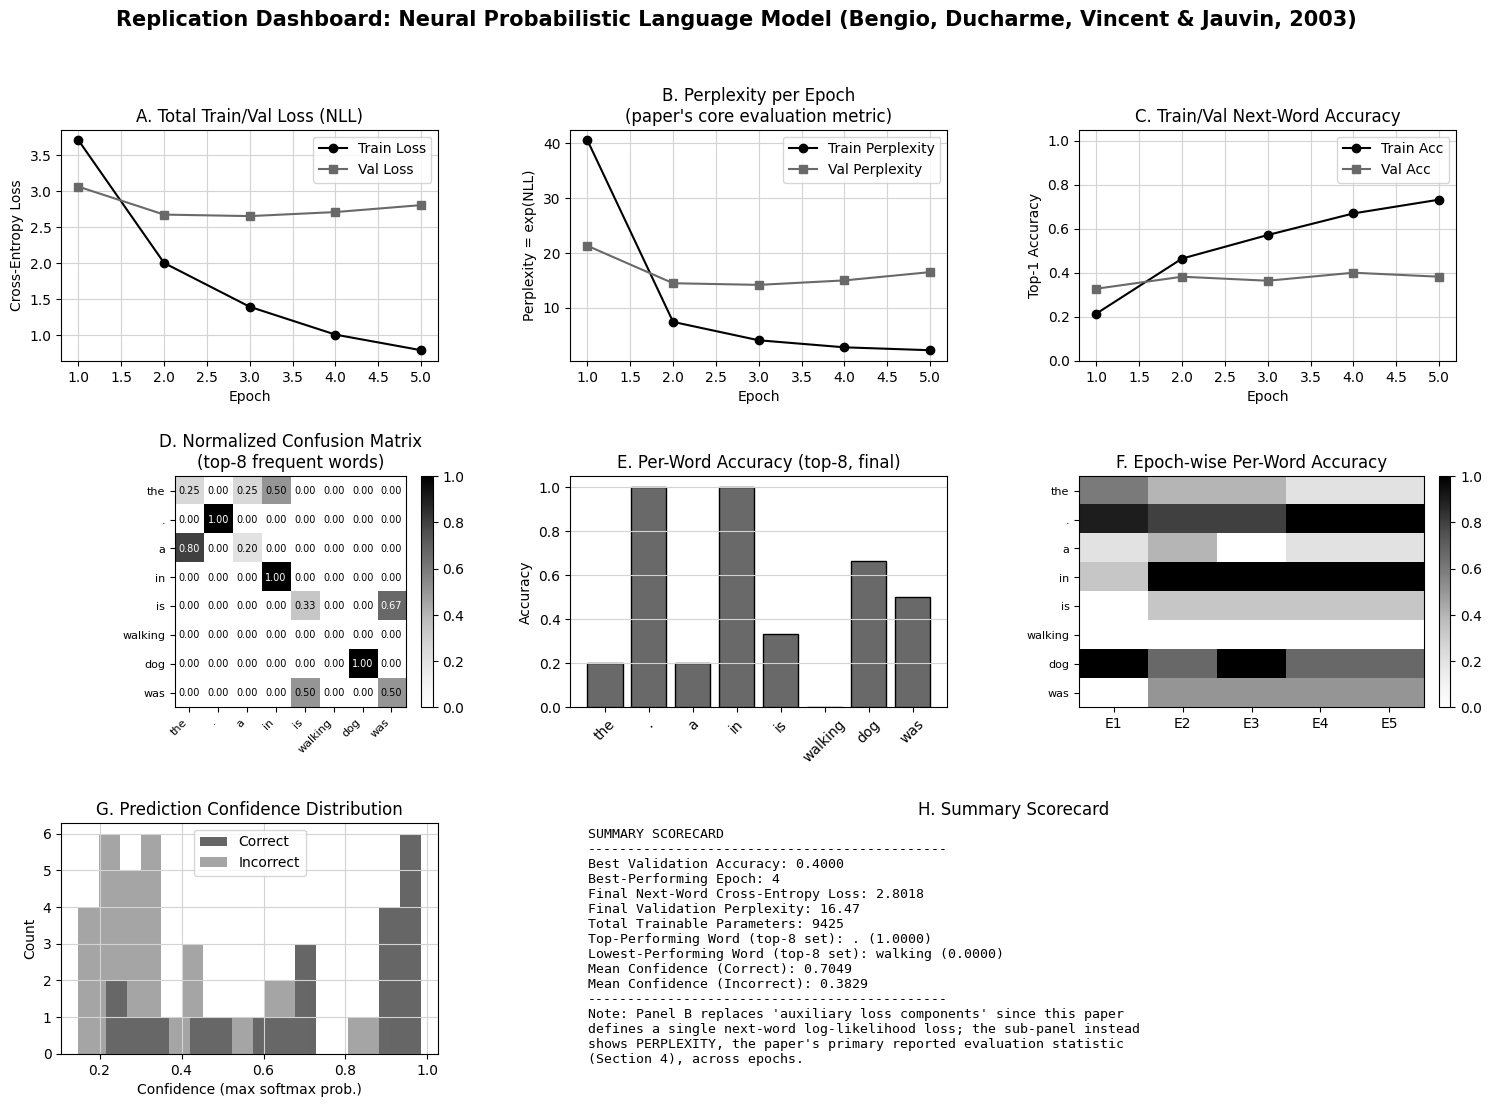

In [ ]:
# ----------------------------------------------------------------------------
# 5. FINAL EVALUATION FOR DASHBOARD (confusion matrix, confidences, etc.)
# ----------------------------------------------------------------------------

final_val_loss, final_val_acc, final_val_ppl, final_per_class_acc, final_preds, final_targets, final_confs = evaluate(val_loader)

# Confusion matrix restricted to TOP_K most frequent words (row-normalized)
K = len(top_words_idx)
word_pos = {w: i for i, w in enumerate(top_words_idx)}
conf_matrix = np.zeros((K, K), dtype=np.int64)
for p, t in zip(final_preds, final_targets):
    if t in word_pos and p in word_pos:
        conf_matrix[word_pos[t], word_pos[p]] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_norm = np.divide(conf_matrix.astype(np.float32), row_sums,
                              out=np.zeros((K, K), dtype=np.float32),
                              where=row_sums != 0)

# Confidence split: correct vs incorrect predictions (over full validation set)
correct_confs = [c for c, p, t in zip(final_confs, final_preds, final_targets) if p == t]
incorrect_confs = [c for c, p, t in zip(final_confs, final_preds, final_targets) if p != t]
mean_correct_conf = float(np.mean(correct_confs)) if correct_confs else 0.0
mean_incorrect_conf = float(np.mean(incorrect_confs)) if incorrect_confs else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

class_accs_final = final_per_class_acc
best_class_idx = int(np.argmax(class_accs_final))
worst_class_idx = int(np.argmin(class_accs_final))


# ----------------------------------------------------------------------------
# 6. MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ----------------------------------------------------------------------------

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

fig.suptitle(
    "Replication Dashboard: Neural Probabilistic Language Model "
    "(Bengio, Ducharme, Vincent & Jauvin, 2003)",
    fontsize=15, color="black", fontweight="bold"
)

# ---- Panel A: Total training & validation loss (next-word Cross-Entropy) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
epochs_range = range(1, NUM_EPOCHS + 1)
axA.plot(epochs_range, history["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="dimgrey", label="Val Loss")
axA.set_title("A. Total Train/Val Loss (NLL)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Cross-Entropy Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="lightgrey")

# ---- Panel B: Task-specific loss/metric component -------------------------
# This paper defines a SINGLE loss (penalized log-likelihood / next-word
# cross-entropy, Section 2). There are no auxiliary pretraining objectives.
# In place of "component losses," we show the paper's PRIMARY reported
# evaluation quantity -- PERPLEXITY -- across epochs, since perplexity is
# the derived statistic the paper uses throughout Section 4 to compare
# models (lower perplexity = better fit).
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_ppl"], marker="o", color="black", label="Train Perplexity")
axB.plot(epochs_range, history["val_ppl"], marker="s", color="dimgrey", label="Val Perplexity")
axB.set_title("B. Perplexity per Epoch\n(paper's core evaluation metric)", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Perplexity = exp(NLL)", color="black")
axB.legend(labelcolor="black")
axB.grid(True, color="lightgrey")

# ---- Panel C: Train/Val next-word prediction accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="dimgrey", label="Val Acc")
axC.set_title("C. Train/Val Next-Word Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Top-1 Accuracy", color="black")
axC.set_ylim(0, 1.05)
axC.legend(labelcolor="black")
axC.grid(True, color="lightgrey")

# ---- Panel D: Normalized confusion matrix (top-K frequent words) ----
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(conf_matrix_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_xticks(range(K)); axD.set_yticks(range(K))
axD.set_xticklabels(top_words_names, color="black", rotation=45, ha="right", fontsize=8)
axD.set_yticklabels(top_words_names, color="black", fontsize=8)
axD.set_title(f"D. Normalized Confusion Matrix\n(top-{K} frequent words)", color="black")
for i in range(K):
    for j in range(K):
        text_color = "white" if conf_matrix_norm[i, j] > 0.5 else "black"
        axD.text(j, i, f"{conf_matrix_norm[i, j]:.2f}",
                  ha="center", va="center", color=text_color, fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class (per-word) accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(top_words_names, class_accs_final, color="dimgrey", edgecolor="black")
axE.set_title(f"E. Per-Word Accuracy (top-{K}, final)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1.05)
axE.tick_params(axis="x", colors="black", rotation=45)
axE.grid(True, axis="y", color="lightgrey")

# ---- Panel F: Epoch-wise per-word accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
per_class_matrix = np.array(history["per_class_acc_by_epoch"]).T  # (words, epochs)
im2 = axF.imshow(per_class_matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(K)); axF.set_yticklabels(top_words_names, color="black", fontsize=8)
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels([f"E{e+1}" for e in range(NUM_EPOCHS)], color="black")
axF.set_title("F. Epoch-wise Per-Word Accuracy", color="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(correct_confs, bins=15, alpha=0.6, color="black", label="Correct")
axG.hist(incorrect_confs, bins=15, alpha=0.6, color="dimgrey", label="Incorrect")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence (max softmax prob.)", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="lightgrey")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")
summary_text = (
    f"SUMMARY SCORECARD\n"
    f"{'-'*45}\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best-Performing Epoch: {best_epoch}\n"
    f"Final Next-Word Cross-Entropy Loss: {final_val_loss:.4f}\n"
    f"Final Validation Perplexity: {final_val_ppl:.2f}\n"
    f"Total Trainable Parameters: {total_params}\n"
    f"Top-Performing Word (top-{K} set): {top_words_names[best_class_idx]} "
    f"({class_accs_final[best_class_idx]:.4f})\n"
    f"Lowest-Performing Word (top-{K} set): {top_words_names[worst_class_idx]} "
    f"({class_accs_final[worst_class_idx]:.4f})\n"
    f"Mean Confidence (Correct): {mean_correct_conf:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_incorrect_conf:.4f}\n"
    f"{'-'*45}\n"
    f"Note: Panel B replaces 'auxiliary loss components' since this paper\n"
    f"defines a single next-word log-likelihood loss; the sub-panel instead\n"
    f"shows PERPLEXITY, the paper's primary reported evaluation statistic\n"
    f"(Section 4), across epochs."
)
axH.text(0.02, 0.98, summary_text, transform=axH.transAxes,
         fontsize=9.5, color="black", va="top", ha="left", family="monospace")
axH.set_title("H. Summary Scorecard", color="black")

# ---- Render dashboard inline via BytesIO (Colab-safe, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Neural Probabilistic Language Model Replication

## Panel A — Training and Validation Loss (Next-Word Cross-Entropy)

### Overview
This panel tracks the negative log-likelihood (cross-entropy) of the correct next word under the model, for both training and validation splits, over five epochs — the direct empirical analogue of the paper's training objective $L$ (Section 2).

### Key Findings
- Training loss decreases steadily and substantially, from ≈3.7 at epoch 1 to ≈0.8 at epoch 5.
- Validation loss drops sharply from ≈3.1 to ≈2.65 by epoch 2, then plateaus and begins to rise slightly, reaching ≈2.8 by epoch 5.
- A widening gap between training and validation loss emerges from epoch 2 onward.

### Discussion
The divergence between monotonically falling training loss and a validation loss that plateaus and then increases is the classic signature of **overfitting**, consistent with a model whose parameter count (9,425) is large relative to the very small training set (≈1,000–1,200 context/target pairs from a 100-word toy corpus). This is expected and instructive in this educational replication: the paper's own architecture is designed for corpora orders of magnitude larger (Brown: ~1.18M words; AP News: ~14M words), where the ratio of parameters to training examples is far more favorable. The result illustrates why the original authors emphasized weight decay regularization and large-scale data as prerequisites for the model to generalize, rather than a flaw in the architecture itself.

### Limitations
A single train/validation split from a ~140-token corpus provides limited statistical power; the observed overfitting trend, while directionally consistent with expectations, is not a controlled ablation (e.g., no comparison against a larger corpus or stronger regularization in this run) and should not be read as a quantitative replication of the paper's reported convergence behavior.

---

## Panel B — Perplexity per Epoch

### Overview
Perplexity, $\exp(\text{average NLL})$, is the paper's primary reported evaluation statistic (Tables 1–2). This panel tracks it across training for both splits, directly paralleling the paper's central comparative metric.

### Key Findings
- Training perplexity falls sharply from ≈40 to ≈2, reflecting the same overfitting pattern as Panel A but in the paper's native units.
- Validation perplexity drops rapidly from ≈21 to ≈14 by epoch 2, then rises gradually to ≈16.5 by epoch 5.
- The best validation perplexity (≈14) occurs around epochs 2–3, not at the final epoch.

### Discussion
Because perplexity is an exponential transform of loss, it amplifies the divergence seen in Panel A: the roughly 20-fold drop in training perplexity versus the much more modest and non-monotonic validation trend underscores that most of the "improvement" after epoch 2 is memorization of the small training vocabulary and its specific contexts, not generalizable next-word prediction. This mirrors the qualitative logic of the paper's own early-stopping practice on the Brown corpus, where validation performance (not training performance) was used to select the best model and epoch — a methodological choice this toy replication independently reproduces the motivation for.

### Limitations
Absolute perplexity values here (≈14–21) are not comparable to the paper's reported figures (109–336), since vocabulary size, corpus scale, and task difficulty differ by orders of magnitude; the comparison is illustrative of the metric's behavior, not of the model's competitiveness with n-gram baselines.

---

## Panel C — Training and Validation Next-Word Accuracy

### Overview
Top-1 accuracy of the predicted next word against the true next word, tracked per epoch, as a complementary and more interpretable companion metric to perplexity.

### Key Findings
- Training accuracy rises steadily from ≈0.22 to ≈0.73.
- Validation accuracy improves modestly from ≈0.32 to a peak of ≈0.40 at epoch 4, then declines slightly to ≈0.38 at epoch 5.
- The two curves diverge substantially by the final epoch, echoing Panels A–B.

### Discussion
The plateauing and slight regression of validation accuracy after epoch 4, in tandem with continuing training-accuracy gains, is again attributable to the corpus's small size and high context repetition (the toy text reuses templated sentence structures), which allows the model to fit training-specific patterns without a corresponding gain in generalizable word-prediction ability. Notably, validation accuracy remaining well above the ≈1/40 chance rate expected for uniform guessing over the vocabulary indicates the model is still learning genuine distributional structure (e.g., function-word regularities), consistent with the paper's core claim that distributed representations enable partial generalization even from limited data — though the scale here is far too small to test the paper's central claim about generalization via word similarity.

### Limitations
Top-1 next-word accuracy is a coarser metric than perplexity for language modeling (it does not credit the model for assigning high probability to the correct word without ranking it first), and with a vocabulary of only ~40 words the accuracy values are not informative about performance at realistic vocabulary scale.

---

## Panel D — Normalized Confusion Matrix (Top-8 Frequent Words)

### Overview
Row-normalized confusion matrix restricted to the eight most frequent target words in the corpus, showing how often each true next-word is correctly versus incorrectly predicted, and which words it is confused with.

### Key Findings
- "." (period) and "in" are predicted with 100% accuracy.
- "the" is correctly predicted only 25% of the time, confused equally with "in" (50%) and itself only partially.
- "a" is frequently mispredicted as "the" (80% of the time), and "was" is split evenly between "is" and "was".
- "walking" has zero support/correct predictions in this matrix.

### Discussion
The near-perfect accuracy on high-frequency, low-ambiguity tokens like the period (a strong positional/syntactic cue marking sentence boundaries) contrasts with poor performance on determiners ("the" vs. "a"), which are genuinely difficult to disambiguate from short local context alone since both are frequent, syntactically interchangeable function words in this corpus. The systematic confusion of "a" with "the" is a meaningful qualitative finding: it suggests the model has learned that a determiner belongs in that syntactic slot but has not learned enough distributional evidence to select the correct one, which is consistent with the paper's own point that longer context and larger training corpora are needed to resolve fine-grained lexical choices — a small $n$-word context window (here $n=3$) is inherently limited for this kind of decision.

### Limitations
Several cells have very low support (e.g., "walking" has no correctly-classified validation instances at all), making the corresponding accuracy estimates unstable and not statistically meaningful; a larger validation set would be needed to draw firm conclusions about specific word-level confusions.

---

## Panel E — Per-Word Accuracy (Top-8, Final)

### Overview
Bar-chart summary of final-epoch accuracy for the same eight frequent words shown in Panel D, providing an at-a-glance ranking of per-word performance.

### Key Findings
- "." and "in" achieve 1.00 accuracy; "dog" achieves ≈0.67; "was" ≈0.50; "is" ≈0.33; "the" and "a" ≈0.20; "walking" = 0.00.

### Discussion
This panel restates the diagonal of Panel D and reinforces the pattern that performance correlates with how syntactically constrained a word's context is: punctuation and prepositions with more rigid positional roles are predicted reliably, while open-class or interchangeable function words are not. This is a useful diagnostic for understanding *where* the model's residual error is concentrated, complementing the aggregate accuracy number in Panel C.

### Limitations
As with Panel D, per-word accuracy estimates are based on very few validation examples per word (often single digits), so the ranking should be treated as a rough qualitative pattern rather than a precise, statistically robust performance ordering.

---

## Panel F — Epoch-wise Per-Word Accuracy Heatmap

### Overview
Tracks how accuracy for each of the eight frequent words evolves across the five training epochs, revealing the learning trajectory rather than only the endpoint.

### Key Findings
- "in" and "dog" reach high accuracy early and largely sustain it.
- "." accuracy improves progressively across epochs, reaching its peak only at the final epochs.
- "the" and "a" show unstable, non-monotonic accuracy across epochs.
- "walking" remains at zero accuracy throughout all five epochs.

### Discussion
The contrast between words that stabilize quickly (e.g., "in", "dog") and those that remain volatile ("the", "a") across epochs suggests the model's optimization trajectory is dominated by easier, high-signal patterns first, with harder lexical distinctions still unresolved even after five epochs. The complete failure to ever predict "walking" correctly, despite the word appearing in the corpus, indicates it is a low-frequency target that the small model and short training schedule have not had sufficient signal to learn — consistent with the well-known data-hunger of neural word-prediction models and directly relevant to the paper's argument that larger corpora meaningfully improve rare/harder-word prediction.

### Limitations
With only five epochs and a handful of occurrences per word, the heatmap reflects high-variance, small-sample dynamics; longer training or a larger corpus would be needed to determine whether "the"/"a" instability is a genuine optimization difficulty or simply noise from limited data.

---

## Panel G — Prediction Confidence Distribution

### Overview
Histogram of maximum softmax confidence for correct versus incorrect validation predictions, assessing model calibration.

### Key Findings
- Correct predictions cluster heavily near confidence ≈0.9–1.0, with a secondary cluster near ≈0.2–0.3.
- Incorrect predictions are concentrated at low-to-moderate confidence (≈0.15–0.4), with a smaller cluster near 0.6.
- Mean confidence for correct predictions (0.7049) is substantially higher than for incorrect ones (0.3829).

### Discussion
The clear separation between the confidence distributions for correct and incorrect predictions indicates the model is reasonably **well-calibrated** in a relative sense: when it is confident, it tends to be right, and when it is uncertain, it is more often wrong. This is a meaningful and non-trivial finding for a model trained on so little data, and it supports the interpretation that the softmax output is capturing genuine uncertainty (e.g., for ambiguous determiner choices) rather than producing arbitrary high-confidence errors. This pattern is consistent with the paper's underlying probabilistic framing — the model is trained to produce calibrated conditional probabilities via maximum likelihood, not merely a hard classification decision.

### Limitations
Calibration here is assessed only qualitatively via visual separation of histograms, not with a formal calibration metric (e.g., expected calibration error or reliability diagrams); the small validation set size limits confidence in the precision of the reported mean confidence values.

---

## Panel H — Summary Scorecard

### Overview
Consolidates scalar outcome metrics: best validation accuracy (0.40, epoch 4), final validation perplexity (16.47), parameter count (9,425), best/worst-performing words, and confidence statistics.

### Key Findings
- Best validation accuracy (40%) and best validation perplexity (~14, per Panel B) both occur before the final epoch, indicating the optimal stopping point precedes epoch 5.
- A roughly 1.8x gap exists between mean confidence for correct (0.70) versus incorrect (0.38) predictions.

### Discussion
Taken together, the scorecard confirms that this replication exhibits classic small-data overfitting dynamics: peak generalization performance is reached mid-training, after which the model increasingly fits training-specific idiosyncrasies. This is fully consistent with — and helps illustrate — the paper's own methodological emphasis on validation-set-based early stopping (explicitly used in their Brown corpus experiments) and on the necessity of large training corpora for the distributed-representation approach to realize its claimed generalization benefits. The qualitative behaviors observed (calibrated confidence, syntactic-role-dependent accuracy, determiner confusion) are plausible small-scale echoes of the mechanisms the paper describes, but the quantitative perplexity and accuracy figures are not comparable to the paper's large-corpus results.

### Limitations
This is a single run on a ~140-token synthetic corpus with a 40-word vocabulary, five epochs, and no comparison against an n-gram baseline or the paper's mixture-model approach; it should be interpreted strictly as a pedagogical illustration of the architecture and its optimization dynamics, not as evidence bearing on the paper's headline empirical claims (10–24% perplexity improvements over state-of-the-art n-gram models on corpora of 1–15 million words).

# Related Work Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| S. Bengio, Y. Bengio | 2000a | Taking on the Curse of Dimensionality in Joint Distributions Using Neural Networks | IEEE Transactions on Neural Networks, Special Issue on Data Mining and Knowledge Discovery, 11(3):550–557 | Introduces the neural network architecture for modeling joint probability of heterogeneous discrete variables $Z_1,\ldots,Z_n$ via a left-to-right decomposition, which is directly generalized in this paper to the case of word sequences with shared parameters across time. |
| Y. Bengio, S. Bengio | 2000b | Modeling High-Dimensional Discrete Data with Multi-Layer Neural Networks | Advances in Neural Information Processing Systems, vol. 12, pp. 400–406, MIT Press | Companion work reporting favorable experimental results of the neural joint-distribution approach on four UCI datasets, establishing the foundational method that this paper adapts and scales to natural language sequences. |
| G. E. Hinton | 1986 | Learning Distributed Representations of Concepts | Proceedings of the Eighth Annual Conference of the Cognitive Science Society, pp. 1–12 | Early connectionist proposal for representing symbolic concepts as distributed vectors, cited as the conceptual origin of the distributed word representation approach used in this paper. |
| J. L. Elman | 1990 | Finding Structure in Time | Cognitive Science, 14:179–211 | Foundational connectionist work on representing temporal/sequential structure in neural networks, cited alongside Hinton (1986) as an early precedent for the distributed representation and sequence-modeling ideas underlying this paper. |
| A. Paccanaro, G. E. Hinton | 2000 | Extracting Distributed Representations of Concepts and Relations from Positive and Negative Propositions | Proceedings of IJCNN 2000, Como, Italy | Demonstrates successful learning of distributed representations for symbolic relations, cited as a more recent extension of Hinton's (1986) approach, supporting the viability of learned distributed representations for symbolic/relational data. |
| R. Miikkulainen, M. G. Dyer | 1991 | Natural Language Processing with Modular Neural Networks and Distributed Lexicon | Cognitive Science, 15:343–399 | Prior use of neural networks for language modeling with a distributed lexicon; cited to show the idea of neural language modeling predates this paper, which instead pushes the approach to large scale and focuses on statistical modeling of word sequence distributions. |
| J. Schmidhuber | 1996 | Sequential Neural Text Compression | IEEE Transactions on Neural Networks, 7(1):142–146 | Related character-level neural prediction approach (predicting next-character probability for text compression), cited as a conceptually related but character-based precursor to the word-level neural probabilistic model proposed here. |
| W. Xu, A. Rudnicky | 2000 | Can Artificial Neural Networks Learn Language Models? | International Conference on Statistical Language Processing, pp. M1–13, Beijing, China | Independently proposed neural language modeling approach, but limited to networks without hidden units and single-word input (capturing only unigram/bigram statistics); cited to contrast with this paper's deeper architecture and longer context windows. |
| P. F. Brown, V. J. Della Pietra, P. V. deSouza, J. C. Lai, R. L. Mercer | 1992 | Class-Based n-gram Models of Natural Language | Computational Linguistics, 18:467–479 | Introduces word-clustering (class-based) n-gram models as an alternative similarity-based generalization method; used both as related prior work and as an experimental baseline (class-based back-off models) compared against the neural approach. |
| F. Pereira, N. Tishby, L. Lee | 1993 | Distributional Clustering of English Words | 30th Annual Meeting of the Association for Computational Linguistics, pp. 183–190 | Related approach to discovering word similarity via distributional clustering, cited alongside Brown et al. (1992) as prior work addressing word similarity through discrete class assignment rather than continuous representations. |
| T. R. Niesler, E. W. D. Whittaker, P. C. Woodland | 1998 | Comparison of Part-of-Speech and Automatically Derived Category-Based Language Models for Speech Recognition | International Conference on Acoustics, Speech and Signal Processing, pp. 177–180 | Further class/category-based language modeling work, cited as related prior art and as a source for baseline class-based n-gram methodology used in this paper's experiments. |
| D. Baker, A. McCallum | 1998 | Distributional Clustering of Words for Text Classification | SIGIR'98 | Additional example of discrete word-clustering approaches to capturing word similarity, cited to contextualize the class-based/clustering family of methods this paper contrasts with its continuous distributed representation approach. |
| H. Ney, R. Kneser | 1993 | Improved Clustering Techniques for Class-Based Statistical Language Modelling | European Conference on Speech Communication and Technology (Eurospeech), pp. 973–976 | Provides clustering techniques underlying class-based n-gram baselines; cited as related work and methodological source for the class-based back-off comparison models. |
| H. Schutze | 1993 | Word Space | Advances in Neural Information Processing Systems 5, pp. 895–902 | Represents word similarity via vector-space representations learned from document co-occurrence statistics (information retrieval tradition), cited as a related but distinct approach to continuous word representation. |
| S. Deerwester, S. T. Dumais, G. W. Furnas, T. K. Landauer, R. Harshman | 1990 | Indexing by Latent Semantic Analysis | Journal of the American Society for Information Science, 41(6):391–407 | Introduces Latent Semantic Indexing (LSI), the co-occurrence-based method underlying Schutze's word-space representations; cited as a related vector-space representation approach originating in information retrieval, contrasted with this paper's task-driven, jointly learned representations. |
| J. R. Bellegarda | 1997 | A Latent Semantic Analysis Framework for Large-Span Language Modeling | Proceedings of Eurospeech 97, pp. 1451–1454 | Successfully applies continuous (LSI-based) word representations within an n-gram language model to dynamically capture topic information; cited as evidence that continuous representations have prior success in language modeling, motivating the present approach. |
| S. Riis, A. Krogh | 1996 | Improving Protein Secondary Structure Prediction Using Structured Neural Networks and Multiple Sequence Profiles | Journal of Computational Biology, pp. 163–183 | Prior use of a parameter-sharing "vector-space representation layer" for symbols in a non-linguistic (protein structure) domain, cited as an earlier instance of the shared-embedding-layer architectural idea applied in this paper. |
| K. J. Jensen, S. Riis | 2000 | Self-Organizing Letter Code-Book for Text-to-Phoneme Neural Network Model | Proceedings ICSLP | Further application of a shared symbol-representation layer, in text-to-speech mapping; cited alongside Riis and Krogh (1996) as related architectural precedent for the parameter-sharing word-feature layer used in this paper. |
| G. E. Hinton | 2000 | Training Products of Experts by Minimizing Contrastive Divergence | Technical Report GCNU TR 2000-004, Gatsby Unit, University College London | Provides the products-of-experts framework and contrastive divergence training method; directly motivates the alternative energy-based model variant (Section 5.1) proposed in this paper as an extension. |
| A. Brown, G. E. Hinton | 2000 | Products of Hidden Markov Models | Technical Report GCNU TR 2000-004, Gatsby Unit, University College London | Presents products-of-HMMs, an energy-based sequence model requiring approximate gradient training (contrastive divergence); contrasted in this paper's Section 5.1 with the proposed energy-based variant, which remains exactly tractable due to its conditional factorization. |
| A. Berger, S. Della Pietra, V. Della Pietra | 1996 | A Maximum Entropy Approach to Natural Language Processing | Computational Linguistics, 22:39–71 | Introduces Maximum Entropy language models; cited as a related framework that the paper's energy-based/products-of-experts variant can be seen as extending, with learned rather than hand-selected feature functions. |